In [1]:
import sys
import os
import glob

print("--- DIAGNOSTYKA I NAPRAWA ---")

# 1. Ustawiamy ścieżki (potwierdzone Twoim screenem)
spark_home = "/usr/local/spark"
os.environ["JAVA_HOME"] = "/usr/local/java"
os.environ["SPARK_HOME"] = spark_home

# 2. Szukamy pliku py4j (serce komunikacji z Javą)
# W Spark 3.1.2 powinien to być py4j-0.10.9-src.zip
py4j_path = glob.glob(os.path.join(spark_home, 'python', 'lib', 'py4j-*-src.zip'))

if not py4j_path:
    print("BŁĄD KRYTYCZNY: Nie widzę pliku py4j w folderze:", os.path.join(spark_home, 'python', 'lib'))
    # Sprawdzamy co tam w ogóle jest
    print("Zawartość folderu lib:", os.listdir(os.path.join(spark_home, 'python', 'lib')))
else:
    print(f"Znaleziono sterownik Javy: {py4j_path[0]}")
    
    # 3. Dodajemy te pliki do Pythona "na siłę" (przed wszystkim innym)
    sys.path.insert(0, py4j_path[0])                 # Dodaj zipa
    sys.path.insert(0, os.path.join(spark_home, 'python')) # Dodaj folder python
    
    # 4. Dopiero teraz importujemy Sparka
    try:
        from pyspark.sql import SparkSession
        
        spark = SparkSession.builder \
            .appName("ParkTablesBuilder") \
            .master("local[*]") \
            .getOrCreate()
            
        print("\nSUKCES! Spark działa.")
        print("Wersja Sparka:", spark.version)
        print("Katalog domowy Sparka:", os.environ["SPARK_HOME"])
        
    except Exception as e:
        print("\nNadal błąd przy uruchamianiu sesji:")
        print(e)

--- DIAGNOSTYKA I NAPRAWA ---
Znaleziono sterownik Javy: /usr/local/spark/python/lib/py4j-0.10.9-src.zip


26/01/11 14:03:21 WARN util.Utils: Your hostname, node1 resolves to a loopback address: 127.0.0.1; using 10.0.2.15 instead (on interface enp0s3)
26/01/11 14:03:21 WARN util.Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/01/11 14:03:22 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).



SUKCES! Spark działa.
Wersja Sparka: 3.1.2
Katalog domowy Sparka: /usr/local/spark


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, from_unixtime, window, avg, sum, lit, lag, when, expr
from pyspark.sql.window import Window

# ==============================================================================
# 1. ŁADOWANIE DANYCH (Zgodnie z Twoimi ścieżkami)
# ==============================================================================

# Dane fundamentalne (Batch)
df_fundamental = spark.read.parquet("hdfs://node1/user/vagrant/static_data_parquet/fundamental_data")
# Dane historyczne (Batch)
df_history = spark.read.parquet("hdfs://node1/user/vagrant/static_data_parquet/eohd_historical_data")
# Dane makro (Batch)
df_macro = spark.read.parquet("hdfs://node1/user/vagrant/static_data_parquet/macro_2025_data")

# Dane "strumieniowe" / tick data (zakładam ścieżkę, podmień jeśli trzeba)
# Traktujemy je tutaj jako batch (snapshot), ale logika jest taka sama jak dla streamu
df_stream = spark.read.parquet("hdfs://node1/user/vagrant/finnhub_parquet")

# ==============================================================================
# PROPOZYCJA 1: Tabela Wskaźników Rynkowych w Czasie Rzeczywistym
# Cel: Live P/E i P/B ratio na podstawie ceny transakcyjnej i danych fundamentalnych
# ==============================================================================

# Krok 1: Przygotowanie danych fundamentalnych (rzutowanie typów i wybór kolumn)
# Dokument wymaga: EPS i BookValue
ref_fundamentals = df_fundamental.select(
    col("Symbol").alias("f_symbol"),
    col("EPS").cast("double").alias("earnings_per_share"),
    col("BookValue").cast("double").alias("book_value_per_share")
)

# Krok 2: Przygotowanie strumienia (konwersja czasu z ms na timestamp)
stream_processed = df_stream.select(
    col("symbol"),
    (col("trade_ts_ms") / 1000).cast("timestamp").alias("trade_timestamp"),
    col("price").cast("double").alias("real_time_price"),
    col("volume").cast("double").alias("trade_volume")
)

# Krok 3: Łączenie (Join) i Obliczenia
# Uwaga: Łączymy po symbolu. W danych strumieniowych masz np. "BINANCE:BTCUSDT", 
# a w fundamentalnych "AAPL". Dla krypto join może nie zadziałać, jeśli nie ma ich w fundamental_data.
# Zakładam, że dla AAPL/AMZN (które są w obu) to zadziała.

df_prop1_indicators = stream_processed.join(
    ref_fundamentals,
    stream_processed.symbol == ref_fundamentals.f_symbol,
    "inner"
).withColumn(
    "live_pe_ratio", 
    col("real_time_price") / col("earnings_per_share")
).withColumn(
    "live_pb_ratio", 
    col("real_time_price") / col("book_value_per_share")
).select(
    "symbol", 
    "trade_timestamp", 
    "real_time_price", 
    "trade_volume", 
    "earnings_per_share", 
    "book_value_per_share", 
    "live_pe_ratio", 
    "live_pb_ratio"
)

print("--- PROPOZYCJA 1: WYNIK (Top 10) ---")
df_prop1_indicators.show(10)
print("--SCHEMAT--")
df_prop1_indicators.printSchema()


# ==============================================================================
# PROPOZYCJA 2: Wykrywanie Anomalii Wolumenu (Dla Krypto i Akcji)
# Cel: Porównanie bieżącego wolumenu (1 min) ze średnią historyczną
# ==============================================================================

# Krok 1: Obliczenie bazy historycznej (średni wolumen dzienny -> średni na minutę)
# Bierzemy średnią z całej dostępnej historii w eohd_historical_data
avg_daily_vol = df_history.groupBy("original_symbol").agg(
    avg("volume").alias("avg_daily_volume")
)

# Skalowanie do minuty (doba ma 1440 minut)
baseline_volume = avg_daily_vol.withColumn(
    "historical_avg_1min_volume", 
    col("avg_daily_volume") / 1440
).select("original_symbol", "historical_avg_1min_volume")

# Krok 2: Agregacja strumienia w oknach 1-minutowych
# Używamy trade_timestamp wyliczonego wcześniej
windowed_stream = stream_processed \
    .groupBy(
        col("symbol"),
        window(col("trade_timestamp"), "1 minute")
    ) \
    .agg(sum("trade_volume").alias("aggregated_volume_1min")) \
    .select(
        col("symbol"),
        col("window.end").alias("window_timestamp"),
        col("aggregated_volume_1min")
    )

# Krok 3: Detekcja anomalii
# Join strumienia z historią. 
# Uwaga: w historycznych symbol to np "AAPL", w streamie "AAPL". 
# Dla krypto w streamie jest "BINANCE:BTCUSDT", w historii może być inaczej.
# Tutaj zakładam zgodność nazw lub join zadziała tylko dla par pasujących.

df_prop2_anomalies = windowed_stream.join(
    baseline_volume,
    windowed_stream.symbol == baseline_volume.original_symbol,
    "left" # Left join, żeby nie zgubić danych live jeśli brak historii
).withColumn(
    "anomaly_score",
    when(col("historical_avg_1min_volume") > 0, 
         col("aggregated_volume_1min") / col("historical_avg_1min_volume"))
    .otherwise(0)
).withColumn(
    "is_anomaly",
    col("anomaly_score") > 10.0  # Próg anomalii np. 10x średnia
)

print("--- PROPOZYCJA 2: WYNIK (Top 1o) ---")
df_prop2_anomalies.show(10)
print("--SCHEMAT--")
df_prop2_anomalies.printSchema()

# ==============================================================================
# PROPOZYCJA 3: Korelacja Makroekonomiczna
# Cel: Zmiana ceny aktywa (T vs T-1) w dniu publikacji wskaźnika makro
# ==============================================================================

# Krok 1: NAPRAWA TYPÓW i Transformacja tabeli Macro
# Najpierw rzutujemy kolumny tekstowe (cpi, unemployment_rate) na liczbowe (double),
# aby pasowały do stóp procentowych.
df_macro_fixed = df_macro \
    .withColumn("cpi", col("cpi").cast("double")) \
    .withColumn("unemployment_rate", col("unemployment_rate").cast("double"))

# Teraz funkcja stack zadziała, bo wszystkie wartości są typu double
macro_events = df_macro_fixed.select(
    col("date").alias("release_date"),
    expr("stack(5, " +
         "'treasury_yield_2y', treasury_yield_2y, " +
         "'treasury_yield_10y', treasury_yield_10y, " +
         "'federal_funds_rate', federal_funds_rate, " +
         "'cpi', cpi, " +
         "'unemployment_rate', unemployment_rate" +
         ") as (indicator_name, indicator_value)")
).where(col("indicator_value").isNotNull())

# Krok 2: Przygotowanie danych historycznych cen (obliczenie zmiany procentowej)
window_spec = Window.partitionBy("original_symbol").orderBy("date")

history_with_change = df_history.withColumn(
    "prev_close", lag("close", 1).over(window_spec)
).withColumn(
    "prev_volume", lag("volume", 1).over(window_spec)
).withColumn(
    "price_change_pct", 
    ((col("close") - col("prev_close")) / col("prev_close")) * 100
).withColumn(
    "volume_change_pct",
    ((col("volume") - col("prev_volume")) / col("prev_volume")) * 100
).select(
    col("original_symbol").alias("related_asset_symbol"),
    col("date").alias("asset_date"),
    col("prev_close").alias("asset_price_before"),
    col("close").alias("asset_price_after_24h"),
    "price_change_pct",
    "volume_change_pct"
)

# Krok 3: Łączenie zdarzeń Makro z reakcją rynku
# Join po dacie (Data publikacji wskaźnika == Data notowania)
df_prop3_macro_impact = macro_events.join(
    history_with_change,
    macro_events.release_date == history_with_change.asset_date,
    "inner"
).select(
    "indicator_name",
    "release_date",
    "indicator_value",
    "related_asset_symbol",
    "asset_price_before",
    "asset_price_after_24h",
    "price_change_pct",
    "volume_change_pct"
)

print("--- PROPOZYCJA 3: WYNIK (Top 10) ---")
df_prop3_macro_impact.show(10)
print("--SCHEMAT--")
df_prop3_macro_impact.printSchema()

# Opcjonalnie: Zapis do HDFS/Hive
# df_prop1_indicators.write.mode("append").saveAsTable("real_time_market_indicators")

26/01/11 14:03:33 WARN datasources.SharedInMemoryCache: Evicting cached table partition metadata from memory due to size constraints (spark.sql.hive.filesourcePartitionFileCacheSize = 262144000 bytes). This may impact query planning performance.


--- PROPOZYCJA 1: WYNIK (Top 10) ---


+------+--------------------+---------------+------------+------------------+--------------------+-----------------+------------------+
|symbol|     trade_timestamp|real_time_price|trade_volume|earnings_per_share|book_value_per_share|    live_pe_ratio|     live_pb_ratio|
+------+--------------------+---------------+------------+------------------+--------------------+-----------------+------------------+
|  NVDA|2026-01-09 17:38:...|         184.89|       100.0|              4.05|               4.892|45.65185185185185|  37.7943581357318|
|  INTC|2026-01-09 17:38:...|         44.995|       652.0|              0.06|               22.32|749.9166666666666| 2.015905017921147|
|  INTC|2026-01-09 17:38:...|          44.99|       200.0|              0.06|               22.32|749.8333333333334|2.0156810035842296|
|  INTC|2026-01-09 17:38:...|          44.99|       200.0|              0.06|               22.32|749.8333333333334|2.0156810035842296|
|  INTC|2026-01-09 17:38:...|          44.99|   

+---------------+-------------------+----------------------+---------------+--------------------------+--------------------+----------+
|         symbol|   window_timestamp|aggregated_volume_1min|original_symbol|historical_avg_1min_volume|       anomaly_score|is_anomaly|
+---------------+-------------------+----------------------+---------------+--------------------------+--------------------+----------+
|BINANCE:BTCUSDT|2026-01-08 21:58:00|     7.558639999999997|BINANCE:BTCUSDT|      3.7033739693264864E7|2.041014508014876E-7|     false|
|BINANCE:BTCUSDT|2026-01-08 21:54:00|     5.876339999999999|BINANCE:BTCUSDT|      3.7033739693264864E7|1.586753065899174...|     false|
|BINANCE:BTCUSDT|2026-01-08 20:51:00|    10.503219999999992|BINANCE:BTCUSDT|      3.7033739693264864E7|2.836121895059428E-7|     false|
|           AAPL|2026-01-08 20:32:00|               17618.0|           AAPL|         37844.76235200364|  0.4655333764849824|     false|
|           INTC|2026-01-09 16:21:00|           

In [3]:
# ==============================================================================
# 4. ZAPIS WYNIKÓW DO PLIKÓW (HDFS)
# ==============================================================================

# Ścieżka bazowa, gdzie wylądują wyniki (możesz ją zmienić)
base_output_path = "hdfs://node1/user/vagrant/final_tables"

# 1. Zapis tabeli wskaźników (Propozycja 1)
# Zapisuje wynik do folderu: hdfs://node1/user/vagrant/output/real_time_market_indicators
print(f"Zapisywanie: {base_output_path}/real_time_market_indicators ...")
df_prop1_indicators.write \
    .mode("overwrite") \
    .parquet(f"{base_output_path}/real_time_market_indicators")

# 2. Zapis tabeli anomalii wolumenu (Propozycja 2)
# Zapisuje wynik do folderu: hdfs://node1/user/vagrant/output/crypto_volume_anomalies
print(f"Zapisywanie: {base_output_path}/crypto_volume_anomalies ...")
df_prop2_anomalies.write \
    .mode("overwrite") \
    .parquet(f"{base_output_path}/crypto_volume_anomalies")

# 3. Zapis tabeli wpływu makroekonomicznego (Propozycja 3)
# Zapisuje wynik do folderu: hdfs://node1/user/vagrant/output/macro_impact_analysis
print(f"Zapisywanie: {base_output_path}/macro_impact_analysis ...")
df_prop3_macro_impact.write \
    .mode("overwrite") \
    .parquet(f"{base_output_path}/macro_impact_analysis")

print("Wszystkie tabele zostały zapisane pomyślnie.")

Zapisywanie: hdfs://node1/user/vagrant/final_tables/real_time_market_indicators ...


26/01/11 14:09:23 WARN hdfs.DFSClient: Caught exception        (778 + 2) / 2625]
java.lang.InterruptedException
	at java.lang.Object.wait(Native Method)
	at java.lang.Thread.join(Thread.java:1252)
	at java.lang.Thread.join(Thread.java:1326)
	at org.apache.hadoop.hdfs.DFSOutputStream$DataStreamer.closeResponder(DFSOutputStream.java:716)
	at org.apache.hadoop.hdfs.DFSOutputStream$DataStreamer.endBlock(DFSOutputStream.java:476)
	at org.apache.hadoop.hdfs.DFSOutputStream$DataStreamer.run(DFSOutputStream.java:652)
                                                                                

Zapisywanie: hdfs://node1/user/vagrant/final_tables/crypto_volume_anomalies ...


26/01/11 14:15:41 WARN hdfs.DFSClient: Caught exception          (87 + 2) / 200]
java.lang.InterruptedException
	at java.lang.Object.wait(Native Method)
	at java.lang.Thread.join(Thread.java:1252)
	at java.lang.Thread.join(Thread.java:1326)
	at org.apache.hadoop.hdfs.DFSOutputStream$DataStreamer.closeResponder(DFSOutputStream.java:716)
	at org.apache.hadoop.hdfs.DFSOutputStream$DataStreamer.closeInternal(DFSOutputStream.java:684)
	at org.apache.hadoop.hdfs.DFSOutputStream$DataStreamer.run(DFSOutputStream.java:680)
                                                                                

Zapisywanie: hdfs://node1/user/vagrant/final_tables/macro_impact_analysis ...


[Stage 29:=================================================>    (185 + 2) / 200]

Wszystkie tabele zostały zapisane pomyślnie.


In [4]:
print(f"Ilosc w pierwszym: {df_prop1_indicators.count()}")
print(f"Drugi: {df_prop2_anomalies.count()}")
print(f"Trzeci: {df_prop3_macro_impact.count()}")      

Ilosc w pierwszym: 28980


Drugi: 1899
Trzeci: 266


In [5]:
df1 = spark.read.parquet(f"{base_output_path}/real_time_market_indicators")
df2 = spark.read.parquet(f"{base_output_path}/crypto_volume_anomalies")
df3 = spark.read.parquet(f"{base_output_path}/macro_impact_analysis")

print(f"Ilosc w pierwszym: {df1.count()}")
print(f"Drugi: {df2.count()}")
print(f"Trzeci: {df3.count()}")   

Ilosc w pierwszym: 28980
Drugi: 1899
Trzeci: 266


--- STATYSTYKA SYMBOLI ---


+------+-----+
|symbol|count|
+------+-----+
|  AAPL|11011|
|  INTC| 7289|
|  AMZN| 6095|
|  NVDA| 3987|
|   AMD|  598|
+------+-----+

--- ZAKRES CZASOWY ---


+---------------------+-----------------------+
|Początek             |Koniec                 |
+---------------------+-----------------------+
|2026-01-07 18:30:36.8|2026-01-09 17:48:47.421|
+---------------------+-----------------------+

--- ZAAWANSOWANE STATYSTYKI (VWAP & ZMIENNOŚĆ) ---


+------+----------------+----------+--------+--------------------+
|symbol|avg_price_simple|VWAP_price|  avg_PE|stddev_PE_volatility|
+------+----------------+----------+--------+--------------------+
|  AAPL|          259.03|     258.9|66417.33|            447.1769|
|  INTC|           44.19|     44.25|  736.45|               7.899|
|  AMZN|          245.19|    245.22|  147.08|              0.7115|
|   AMD|          206.44|    206.43|  108.08|              0.2548|
|  NVDA|          185.08|    185.08|    45.7|              0.0681|
+------+----------------+----------+--------+--------------------+

--- POBIERANIE DANYCH DO PANDAS ---


/usr/local/spark/python/pyspark/sql/pandas/conversion.py:178: FutureWarning: Passing unit-less datetime64 dtype to .astype is deprecated and will raise in a future version. Pass 'datetime64[ns]' instead
  series = series.astype(t, copy=False)


--- GENEROWANIE WYKRESÓW LINIOWYCH ---


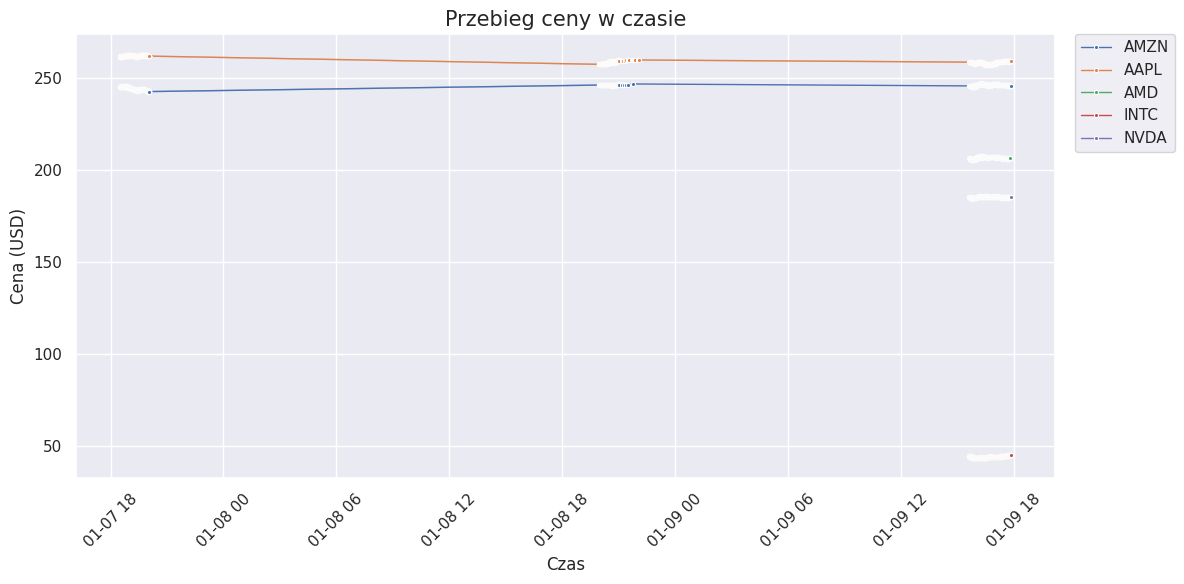

--- GENEROWANIE WYKRESU ROZKŁADU (BOXPLOT) ---


/tmp/ipykernel_13062/2822776340.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


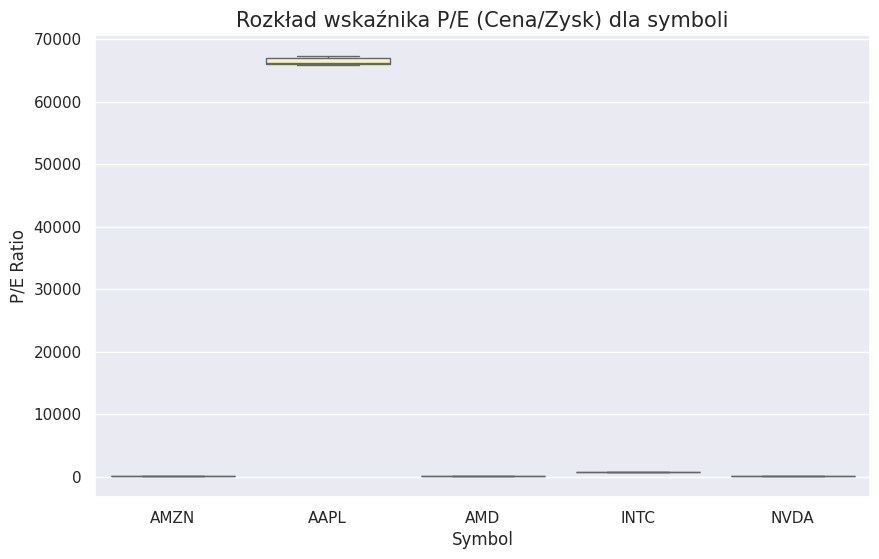

--- PODSUMOWANIE OBROTÓW ---


[Stage 251:==================================================>(2623 + 2) / 2625]

+------+----------------+--------------------+
|symbol|total_volume_sum|total_turnover_value|
+------+----------------+--------------------+
|AAPL  |1659325.0       |4.2959686594000024E8|
|AMZN  |1024049.0       |2.5111289659499985E8|
|NVDA  |665744.0        |1.232183727799999E8 |
|INTC  |1373843.0       |6.079177109499996E7 |
|AMD   |98615.0         |2.0357068740000002E7|
+------+----------------+--------------------+



In [13]:
import numpy as np
from pyspark.sql.functions import col, min, max, sum, count, desc, stddev, avg, round
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- FIX NA BŁĄD NUMPY (Monkey Patch) ---
# To naprawia błąd "module 'numpy' has no attribute 'bool'", który widziałeś wcześniej
np.bool = bool
np.object = object

# Zakładam, że df_prop1_indicators jest już wczytane w Sparku
# 0. Szybka konwersja typów
df_analyzed = df_prop1_indicators \
    .withColumn("trade_timestamp", col("trade_timestamp").cast("timestamp")) \
    .withColumn("real_time_price", col("real_time_price").cast("double")) \
    .withColumn("trade_volume", col("trade_volume").cast("double")) \
    .withColumn("live_pe_ratio", col("live_pe_ratio").cast("double")) \
    .withColumn("live_pb_ratio", col("live_pb_ratio").cast("double"))

# ============================================================
# 1. Liczenie symboli
# ============================================================
print("--- STATYSTYKA SYMBOLI ---")
symbol_counts = df_analyzed.groupBy("symbol").count().orderBy(desc("count"))
symbol_counts.show()

# ============================================================
# 2. Zakres Czasowy (Twoje)
# ============================================================
print("--- ZAKRES CZASOWY ---")
df_analyzed.select(
    min("trade_timestamp").alias("Początek"), 
    max("trade_timestamp").alias("Koniec")
).show(truncate=False)

# ============================================================
# 2b. VWAP i ZMIENNOŚĆ (Zaawansowana Statystyka)
# ============================================================
print("--- ZAAWANSOWANE STATYSTYKI (VWAP & ZMIENNOŚĆ) ---")

# VWAP = Suma(Cena * Wolumen) / Suma(Wolumen)
# StdDev = Odchylenie standardowe P/E (im wyższe, tym bardziej niestabilna wycena)

advanced_stats = df_analyzed.groupBy("symbol").agg(
    round(avg("real_time_price"), 2).alias("avg_price_simple"),
    round(
        sum(col("real_time_price") * col("trade_volume")) / sum("trade_volume"), 2
    ).alias("VWAP_price"),
    round(avg("live_pe_ratio"), 2).alias("avg_PE"),
    round(stddev("live_pe_ratio"), 4).alias("stddev_PE_volatility")
).orderBy(desc("stddev_PE_volatility"))

advanced_stats.show()

# ============================================================
# 3, 4, 5. WYKRESY CZASOWE
# ============================================================
print("--- POBIERANIE DANYCH DO PANDAS ---")
pdf = df_analyzed.select(
    "symbol", "trade_timestamp", "real_time_price", "live_pe_ratio", "live_pb_ratio"
).orderBy("trade_timestamp").toPandas()

sns.set_theme(style="darkgrid")

def rysuj_wykres_czasowy(y_col, label_y, tytul):
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=pdf, 
        x="trade_timestamp", 
        y=y_col, 
        hue="symbol", 
        marker="o",
        markersize=3,    # Małe kropki
        linewidth=1      
    )
    plt.title(tytul, fontsize=15)
    plt.xlabel("Czas", fontsize=12)
    plt.ylabel(label_y, fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print("--- GENEROWANIE WYKRESÓW LINIOWYCH ---")
rysuj_wykres_czasowy("real_time_price", "Cena (USD)", "Przebieg ceny w czasie")
# rysuj_wykres_czasowy("live_pe_ratio", "P/E Ratio", "Wskaźnik Cena/Zysk") # Opcjonalnie

# ============================================================
# 5b. WYKRES PUDEŁKOWY (BOXPLOT) - Rozkład P/E
# ============================================================
print("--- GENEROWANIE WYKRESU ROZKŁADU (BOXPLOT) ---")
# Ten wykres pokazuje "kto jest drogi" i "kto ma duży rozrzut wyceny"

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=pdf,
    x="symbol",
    y="live_pe_ratio",
    palette="Set3"
)
plt.title("Rozkład wskaźnika P/E (Cena/Zysk) dla symboli", fontsize=15)
plt.ylabel("P/E Ratio", fontsize=12)
plt.xlabel("Symbol", fontsize=12)
plt.show()

# ============================================================
# 6 & 7. Agregacje Wolumenu
# ============================================================
print("--- PODSUMOWANIE OBROTÓW ---")
turnover_df = df_analyzed.withColumn(
    "turnover_value", 
    col("trade_volume") * col("real_time_price")
).groupBy("symbol").agg(
    sum("trade_volume").alias("total_volume_sum"),
    sum("turnover_value").alias("total_turnover_value")
).orderBy(desc("total_turnover_value"))

turnover_df.show(truncate=False)

--- STATYSTYKA ANOMALII WG SYMBOLU ---


+---------------+-----+
|         symbol|false|
+---------------+-----+
|           AAPL|  303|
|   IC MARKETS:1|  321|
|           INTC|  132|
|BINANCE:BTCUSDT|  358|
|          BRK.B|  105|
|            AMD|  122|
|BINANCE:ETHUSDT|  132|
|           AMZN|  294|
|           NVDA|  132|
+---------------+-----+

--- POBIERANIE DANYCH DO WYKRESÓW ---


/usr/local/spark/python/pyspark/sql/pandas/conversion.py:178: FutureWarning: Passing unit-less datetime64 dtype to .astype is deprecated and will raise in a future version. Pass 'datetime64[ns]' instead
  series = series.astype(t, copy=False)


--- GENEROWANIE WYKRESU WOLUMENU ---


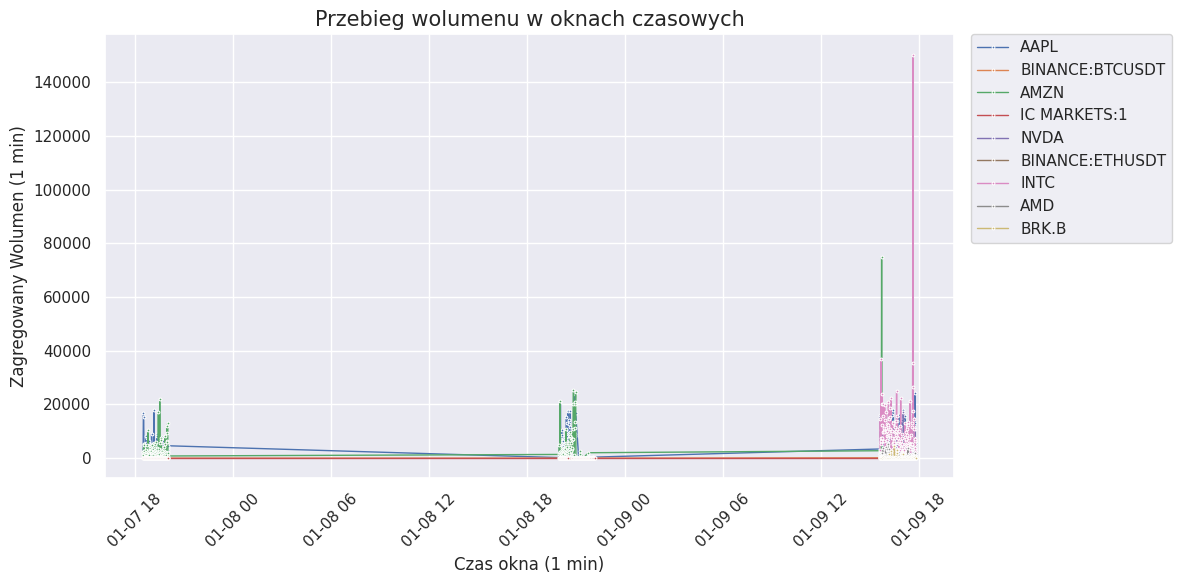

--- GENEROWANIE WYKRESU SCORINGU ANOMALII ---


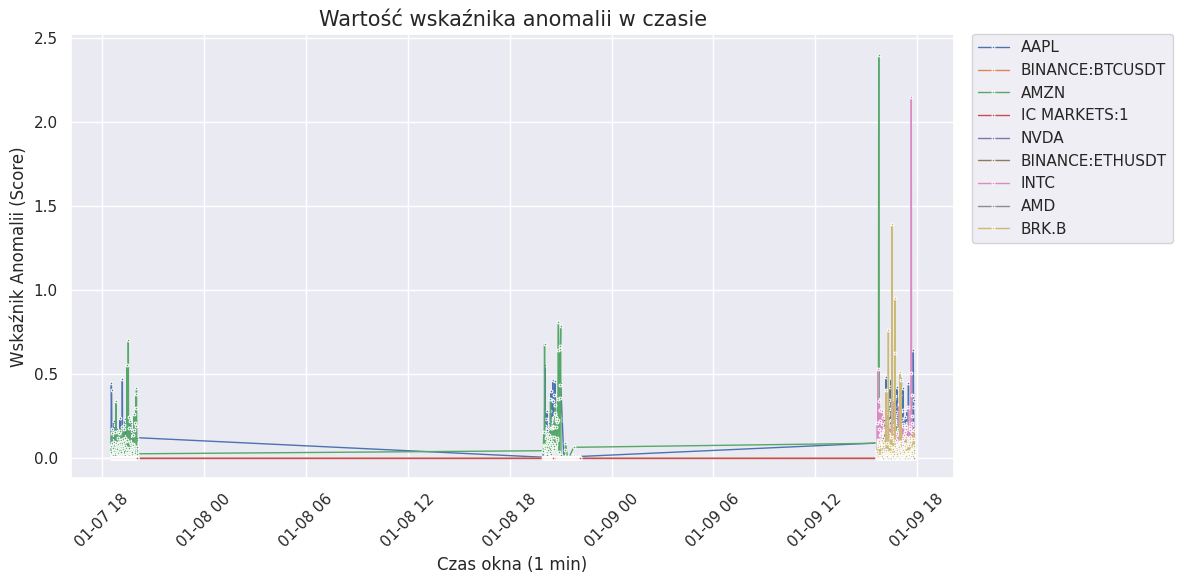

--- RANKING: 10 NAJWIĘKSZYCH ODCHYLEŃ ---


+------+----------------+----------------------+-------------+
|symbol|window_timestamp|aggregated_volume_1min|anomaly_score|
+------+----------------+----------------------+-------------+
+------+----------------+----------------------+-------------+

--- GENEROWANIE HISTOGRAMU SCORINGU ---


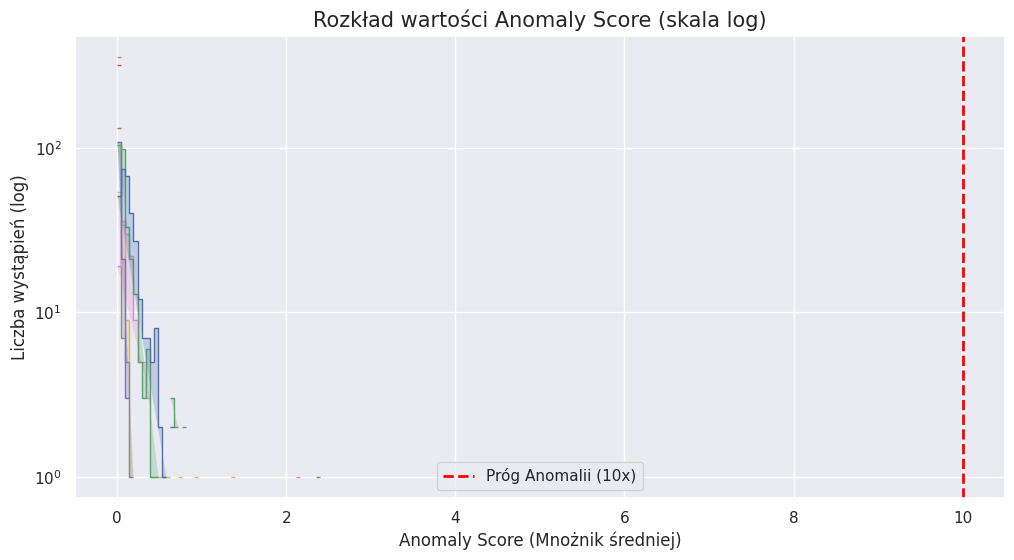

In [12]:
from pyspark.sql.functions import col, count, when, desc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# 1. ZLICZANIE ANOMALII (Ile True / Ile False dla każdego symbolu)
# ============================================================
print("--- STATYSTYKA ANOMALII WG SYMBOLU ---")

# Używamy funkcji pivot, aby obrócić wartości 'true'/'false' na kolumny
# Dzięki temu zobaczysz wynik w czytelnej tabelce
anomaly_counts = df_prop2_anomalies.groupBy("symbol") \
    .pivot("is_anomaly") \
    .count() \
    .na.fill(0)  # Zamienia null na 0, jeśli np. nie było żadnej anomalii

# Wyświetlenie wyników
anomaly_counts.show()

# ============================================================
# PRZYGOTOWANIE DANYCH DO WYKRESÓW
# ============================================================
print("--- POBIERANIE DANYCH DO WYKRESÓW ---")

# Wybieramy tylko potrzebne kolumny i sortujemy po czasie
# Limitujemy np. do ostatnich 2000 punktów jeśli danych jest bardzo dużo, 
# ale tutaj pobieramy całość posortowaną.
pdf_anomalies = df_prop2_anomalies.select(
    "symbol", 
    "window_timestamp", 
    "aggregated_volume_1min", 
    "anomaly_score"
).orderBy("window_timestamp").toPandas()

# Ustawienie stylu
sns.set_theme(style="darkgrid")

# Funkcja rysująca (z małymi kropkami, o które prosiłeś)
def rysuj_wykres_anomalii(y_col, label_y, tytul):
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(
        data=pdf_anomalies, 
        x="window_timestamp", 
        y=y_col, 
        hue="symbol", 
        marker="o",
        markersize=2,    # <--- MAŁE KROPKI (zgodnie z życzeniem)
        linewidth=1
    )
    
    plt.title(tytul, fontsize=15)
    plt.xlabel("Czas okna (1 min)", fontsize=12)
    plt.ylabel(label_y, fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ============================================================
# 2. WYKRES: aggregated_volume_1min od window_timestamp
# ============================================================
print("--- GENEROWANIE WYKRESU WOLUMENU ---")
rysuj_wykres_anomalii(
    "aggregated_volume_1min", 
    "Zagregowany Wolumen (1 min)", 
    "Przebieg wolumenu w oknach czasowych"
)

# ============================================================
# 3. WYKRES: anomaly_score od window_timestamp
# ============================================================
print("--- GENEROWANIE WYKRESU SCORINGU ANOMALII ---")
# Możemy dodać linię pozioma na poziomie 10 (Twój próg anomalii), żeby było widać co przekracza
rysuj_wykres_anomalii(
    "anomaly_score", 
    "Wskaźnik Anomalii (Score)", 
    "Wartość wskaźnika anomalii w czasie"
)

# ============================================================
# 4. RANKING TOP 10 NAJSILNIEJSZYCH ANOMALII
# ============================================================
print("--- RANKING: 10 NAJWIĘKSZYCH ODCHYLEŃ ---")

# Filtrujemy tylko anomalie (is_anomaly=True) i sortujemy malejąco po score
top_anomalies = df_prop2_anomalies.filter(col("is_anomaly") == True) \
    .select("symbol", "window_timestamp", "aggregated_volume_1min", "anomaly_score") \
    .orderBy(desc("anomaly_score"))

# Wyświetlamy
top_anomalies.show(10, truncate=False)

# ============================================================
# 5. HISTOGRAM ROZKŁADU SCORINGU
# ============================================================
print("--- GENEROWANIE HISTOGRAMU SCORINGU ---")
# To pozwoli zobaczyć, jak rzadkie są wysokie wyniki.
# Używamy skali logarytmicznej na osi Y, bo zazwyczaj "zwykłych" transakcji jest miliony, a anomalii mało.

plt.figure(figsize=(12, 6))
sns.histplot(
    data=pdf_anomalies,
    x="anomaly_score",
    hue="symbol",
    element="step",
    bins=50,
    log_scale=(False, True) # Oś Y logarytmiczna, żeby słupki anomalii były widoczne
)
plt.title("Rozkład wartości Anomaly Score (skala log)", fontsize=15)
plt.xlabel("Anomaly Score (Mnożnik średniej)", fontsize=12)
plt.ylabel("Liczba wystąpień (log)", fontsize=12)
# Rysujemy linię odcięcia (próg anomalii np. 10)
plt.axvline(10, color='red', linestyle='--', linewidth=2, label='Próg Anomalii (10x)')
plt.legend()
plt.show()

--- 1. KTÓRY WSKAŹNIK NAJBARDZIEJ RUSZA RYNKIEM? ---


+------------------+--------------+--------------------------+---------------------------+
|    indicator_name|liczba_zdarzen|srednia_zmiennosc_ceny_abs|srednia_zmiana_wolumenu_abs|
+------------------+--------------+--------------------------+---------------------------+
| treasury_yield_2y|            58|                    2.0942|                      33.19|
|treasury_yield_10y|            58|                    2.0942|                      33.19|
|federal_funds_rate|            58|                    2.0942|                      33.19|
| unemployment_rate|            50|                    2.0386|                      34.72|
|               cpi|            42|                    2.0036|                      22.41|
+------------------+--------------+--------------------------+---------------------------+

--- 2. NAJWIĘKSZE REAKCJE RYNKOWE ---


+------------+------------------+--------------------+---------------+-------------------+
|release_date|    indicator_name|related_asset_symbol|indicator_value|   price_change_pct|
+------------+------------------+--------------------+---------------+-------------------+
|  2025-08-01| unemployment_rate|                AMZN|            4.3| -8.269616846781433|
|  2025-08-01|treasury_yield_10y|                AMZN|           4.26| -8.269616846781433|
|  2025-08-01|federal_funds_rate|                AMZN|           4.33| -8.269616846781433|
|  2025-08-01|               cpi|                AMZN|        323.976| -8.269616846781433|
|  2025-08-01| treasury_yield_2y|                AMZN|            3.7| -8.269616846781433|
|  2025-10-01|federal_funds_rate|                INTC|           4.09|  7.123695976154995|
|  2025-10-01|treasury_yield_10y|                INTC|           4.06|  7.123695976154995|
|  2025-10-01| treasury_yield_2y|                INTC|           3.52|  7.123695976154995|

/tmp/ipykernel_13062/7683823.py:49: FutureWarning:                              

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


--- GENEROWANIE WYKRESU ROZKŁADU (BOXPLOT) ---


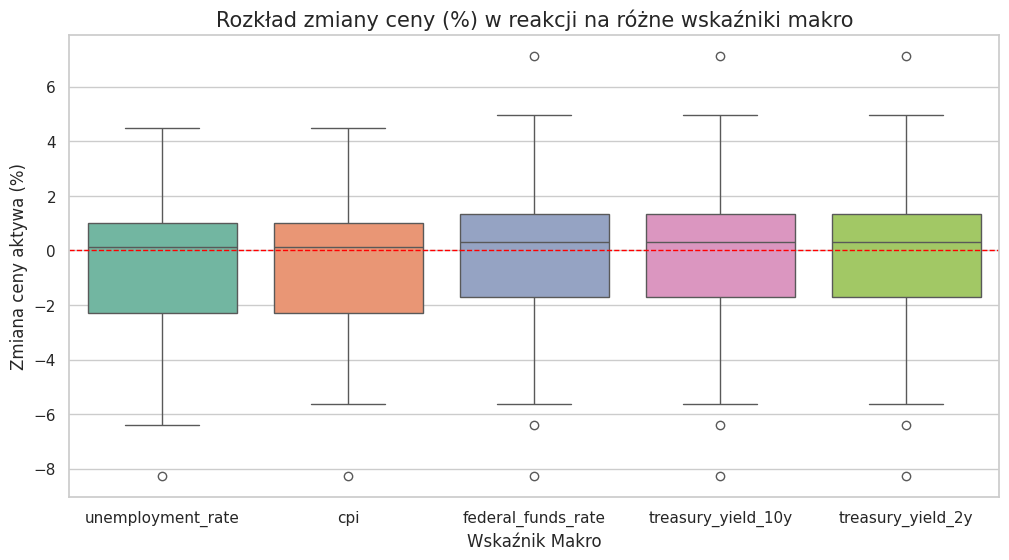

--- GENEROWANIE WYKRESU KORELACJI DLA: FEDERAL_FUNDS_RATE ---


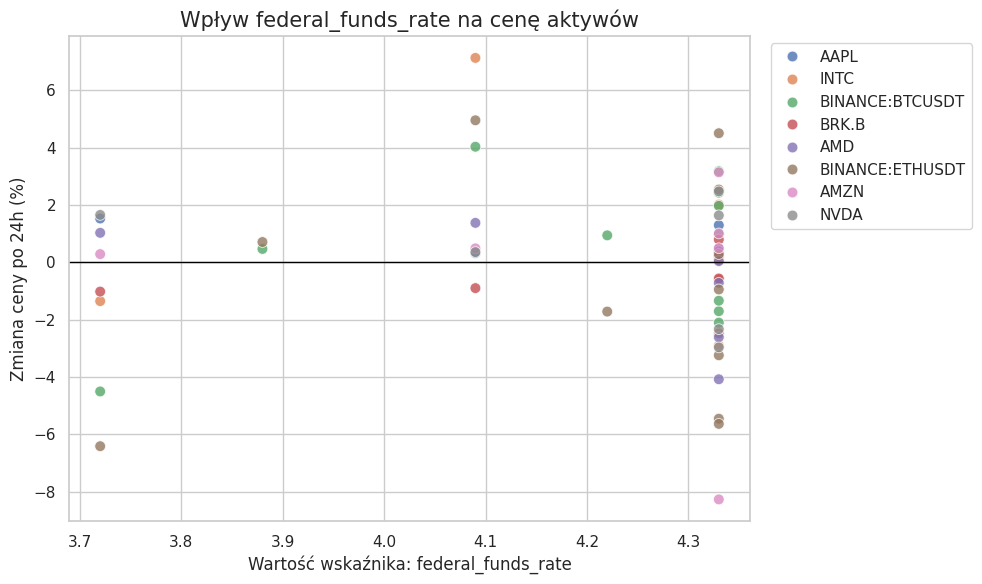

In [9]:
from pyspark.sql.functions import col, abs, avg, count, desc, round
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Zakładam, że ramka nazywa się tak, jak w poprzednich krokach
df_macro = df_prop3_macro_impact

# ============================================================
# 1. RANKING "SIŁY WSTRZĄSU" (Impact Strength)
# ============================================================
print("--- 1. KTÓRY WSKAŹNIK NAJBARDZIEJ RUSZA RYNKIEM? ---")
# Liczymy średnią wartość BEZWZGLĘDNĄ zmiany ceny (abs).
# Interesuje nas siła ruchu, a nie kierunek (wzrost/spadek).
impact_strength = df_macro.groupBy("indicator_name").agg(
    count("indicator_name").alias("liczba_zdarzen"),
    round(avg(abs(col("price_change_pct"))), 4).alias("srednia_zmiennosc_ceny_abs"),
    round(avg(abs(col("volume_change_pct"))), 2).alias("srednia_zmiana_wolumenu_abs")
).orderBy(desc("srednia_zmiennosc_ceny_abs"))

impact_strength.show()

# ============================================================
# 2. TOP 10 NAJWIĘKSZYCH REAKCJI (Konkretne zdarzenia)
# ============================================================
print("--- 2. NAJWIĘKSZE REAKCJE RYNKOWE ---")
df_macro.select(
    "release_date", "indicator_name", "related_asset_symbol", 
    "indicator_value", "price_change_pct"
).orderBy(desc(abs(col("price_change_pct")))).show(10)

# ============================================================
# PRZYGOTOWANIE DANYCH DO WYKRESÓW
# ============================================================
# Pobieramy dane do Pandasa. 
# Filtrujemy null-e, żeby wykresy się nie wysypały.
pdf_macro = df_macro.filter(col("price_change_pct").isNotNull()).toPandas()

# Ustawienie stylu
sns.set_theme(style="whitegrid")

# ============================================================
# 3. WYKRES PUDEŁKOWY (BOXPLOT) - Rozkład reakcji
# ============================================================
print("--- GENEROWANIE WYKRESU ROZKŁADU (BOXPLOT) ---")
# Boxplot idealnie pokazuje medianę i "wąsy" (zakres typowych reakcji) oraz kropki (odstępstwa/anomalie)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=pdf_macro,
    x="indicator_name",
    y="price_change_pct",
    palette="Set2"
)
plt.title("Rozkład zmiany ceny (%) w reakcji na różne wskaźniki makro", fontsize=15)
plt.xlabel("Wskaźnik Makro", fontsize=12)
plt.ylabel("Zmiana ceny aktywa (%)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Linia pozioma na 0% dla odniesienia
plt.show()

# ============================================================
# 4. WYKRES PUNKTOWY (SCATTER) - Korelacja dla wybranego wskaźnika
# ============================================================
# Wybierzmy jeden ciekawy wskaźnik, np. 'federal_funds_rate' (Stopy procentowe) 
# lub 'cpi' (Inflacja), aby zobaczyć czy wyższa wartość wskaźnika = spadek giełdy.

target_indicator = "federal_funds_rate"  # Możesz zmienić na 'cpi' lub 'unemployment_rate'
subset_pdf = pdf_macro[pdf_macro['indicator_name'] == target_indicator]

print(f"--- GENEROWANIE WYKRESU KORELACJI DLA: {target_indicator.upper()} ---")

if not subset_pdf.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=subset_pdf,
        x="indicator_value",
        y="price_change_pct",
        hue="related_asset_symbol", # Różne kolory dla różnych aktywów
        s=60, # Rozmiar punktu
        alpha=0.8
    )
    plt.title(f"Wpływ {target_indicator} na cenę aktywów", fontsize=15)
    plt.xlabel(f"Wartość wskaźnika: {target_indicator}", fontsize=12)
    plt.ylabel("Zmiana ceny po 24h (%)", fontsize=12)
    plt.axhline(0, color='black', linestyle='-', linewidth=1)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print(f"Brak danych dla wskaźnika {target_indicator}")